# AI-Powered Customer Feedback Analyzer

## Business Question
Can an LLM automatically read and categorize customer reviews at scale, replacing the manual work of reading through thousands of reviews individually?

## Tools Used
Python, Google Gemini API (gemini-3.5-flash-lite), pandas, matplotlib

## Approach
1. Loaded real customer review data from a Women's E-Commerce Clothing dataset
2. Designed a structured prompt asking Gemini to classify each review's sentiment and extract its main theme
3. Ran this analysis across a sample of reviews via the Gemini API
4. Aggregated the AI-generated labels to find patterns across the sample

## Key Finding
Out of a 10-review sample, sentiment broke down as 5 Positive, 4 Mixed, 1 Negative. Notably, sizing and fit issues appeared as the dominant theme in half the reviews, regardless of overall sentiment (including several "Positive" reviews) — suggesting this is a business-wide pattern worth addressing through better size guides or fit descriptions, not an issue isolated to any one product.

## Business Implication
This approach could replace manual review reading entirely: rather than a team skimming thousands of reviews, an LLM can process them at scale and flag recurring themes automatically, letting a business focus human attention on the patterns that matter.

## A Note on Building This
This project involved real-world API integration challenges: migrating from a deprecated Google SDK to its replacement, resolving a Python environment/compilation issue by building a fresh environment, and navigating free-tier rate limits by switching models and pacing requests. These are genuine engineering problems, not just prompt-writing.

In [ ]:
API_KEY = input('Enter your Gemini API key: ')

In [3]:
from google import genai

client = genai.Client(api_key=API_KEY)
response = client.models.generate_content(
    model='gemini-3.8-flash',
    contents='Say hello in one sentence.'
)
print(response.text)

Hello, I hope you are having a wonderful day!


In [5]:
import pandas as pd
reviews = pd.read_csv('/Users/shobarathore/Downloads/Portfolio Projects/ai-review-analyze/Womens Clothing E-Commerce Reviews.csv')
reviews.head()

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
4,4,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


In [6]:
reviews[['Review Text', 'Rating', 'Department Name']].info()

<class 'pandas.DataFrame'>
RangeIndex: 23486 entries, 0 to 23485
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Review Text      22641 non-null  str  
 1   Rating           23486 non-null  int64
 2   Department Name  23472 non-null  str  
dtypes: int64(1), str(2)
memory usage: 550.6 KB


In [7]:
sample = reviews.dropna(subset=['Review Text']).sample(20, random_state=1)
sample[['Review Text', 'Rating', 'Department Name']]

,Review Text,Rating,Department Name
6257,"I'm taking this to hawaii for the holidays, i'...",5,Dresses
7519,I purchased this sweater in the blue and i lov...,4,Tops
18421,Absolutely in love with this top. the embroide...,5,Tops
1329,"In the midst of the end-of-winter doldrums, i ...",4,Tops
6069,"According to the label, this dress can be hand...",2,Dresses
1894,I first bought the red & green at the store. w...,5,Tops
13505,This is a great dress that i was eyeing for so...,4,Dresses
16236,This is a unique blouse and well worth a try. ...,4,Trend
7126,Yeah i know that sounds ridiculous. but this i...,4,Bottoms
544,I purchased this dress because i have a simila...,5,Dresses


In [14]:
review_text = sample.iloc[0]['Review Text']

prompt = f"""Analyze this customer review. Respond in exactly this format:
Sentiment: [Positive/Negative/Mixed]
Theme: [one short phrase describing the main topic, e.g. "sizing issue", "fabric quality", "great fit"]

Review: {review_text}"""

response = client.models.generate_content(
    model='gemini-flash-latest',
    contents=prompt
)
print(response.text)

Sentiment: Positive
Theme: great dress


In [24]:
sample = reviews.dropna(subset=['Review Text']).sample(10, random_state=1)

In [25]:
import time

results = []

for i, row in sample.iterrows():
    prompt = f"""Analyze this customer review. Respond in exactly this format:
Sentiment: [Positive/Negative/Mixed]
Theme: [one short phrase describing the main topic]

Review: {row['Review Text']}"""
    
    response = client.models.generate_content(
        model='gemini-3.5-flash-lite',
        contents=prompt
    )
    results.append(response.text)
    print(f"Done {i}")
    time.sleep(3)

Done 6257
Done 7519
Done 18421
Done 1329
Done 6069
Done 1894
Done 13505
Done 16236
Done 7126
Done 544


In [27]:
for r in results: print(r); print('---')

Sentiment: Positive
Theme: Outfit styling and vacation wear
---
Sentiment: Mixed
Theme: Sizing and fit of the sweater
---
Sentiment: Positive
Theme: Style and fit of the top
---
Sentiment: Positive
Theme: Clothing comfort and versatility
---
Sentiment: Negative
Theme: Poor product quality and misleading care instructions
---
Sentiment: Positive
Theme: Love for stylish and stretchy shirts
---
Sentiment: Mixed
Theme: Quality and sizing of a discounted dress
---
Sentiment: Mixed
Theme: Fit and flattering style
---
Sentiment: Mixed
Theme: Sizing and fit issues
---
Sentiment: Positive
Theme: Dress fit and fabric quality
---


In [29]:
sentiments = [r.split('Sentiment: ')[1].split('\n')[0] for r in results]

In [30]:
sentiments

['Positive',
 'Mixed',
 'Positive',
 'Positive',
 'Negative',
 'Positive',
 'Mixed',
 'Mixed',
 'Mixed',
 'Positive']

In [31]:
import pandas as pd

In [32]:
pd.Series(sentiments).value_counts()

Positive    5
Mixed       4
Negative    1
Name: count, dtype: int64

In [33]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


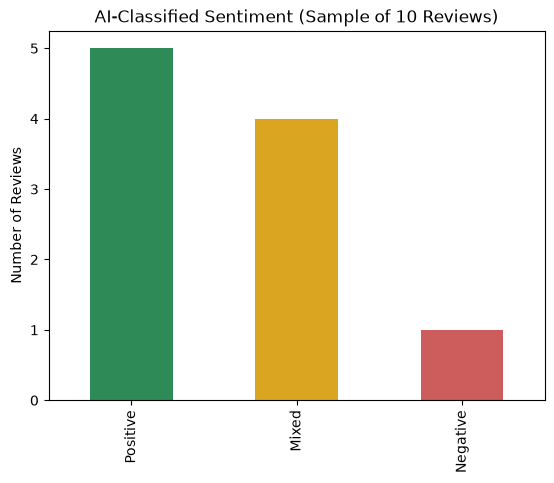

In [34]:
pd.Series(sentiments).value_counts().plot(kind='bar', color=['seagreen','goldenrod','indianred'], title='AI-Classified Sentiment (Sample of 10 Reviews)')
plt.ylabel('Number of Reviews')
plt.show()